In [19]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler

In [20]:
df = pd.read_csv("income.csv")   # or your dataset name
df.head()

,Name,Age,Income($)
0,Rob,27,70000
1,Michael,29,90000
2,Mohan,29,61000
3,Ismail,28,60000
4,Kory,42,150000


<function matplotlib.pyplot.show(close=None, block=None)>

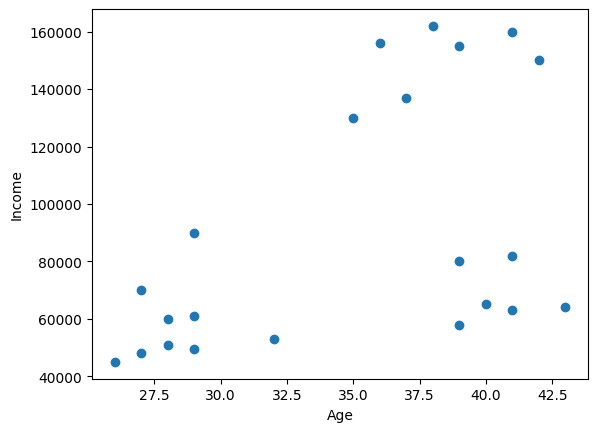

In [21]:
plt.scatter(df.Age, df['Income($)'])
plt.xlabel('Age')
plt.ylabel('Income')
plt.show

In [22]:
scaler = MinMaxScaler()

df[['Age', 'Income($)']] = scaler.fit_transform(df[['Age','Income($)' ]])
df.head()

,Name,Age,Income($)
0,Rob,0.058824,0.213675
1,Michael,0.176471,0.384615
2,Mohan,0.176471,0.136752
3,Ismail,0.117647,0.128205
4,Kory,0.941176,0.897436


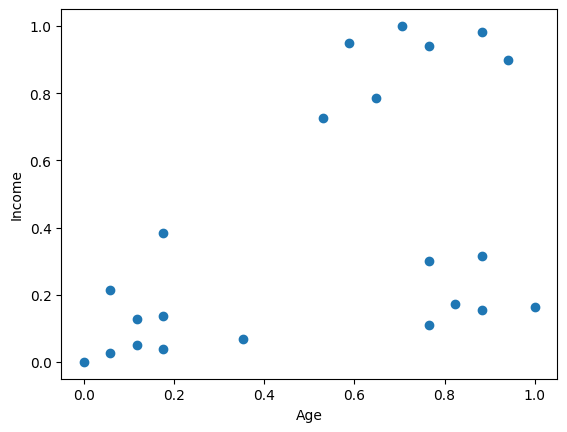

In [23]:
plt.scatter(df.Age, df['Income($)'])
plt.xlabel('Age')
plt.ylabel('Income')
plt.show()

In [24]:
km = KMeans(n_clusters=3, random_state=0)
y_predicted = km.fit_predict(df[['Age', 'Income($)']])
y_predicted

array([0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 2, 2, 2, 2, 2, 2],
      dtype=int32)

In [25]:
df['cluster'] = y_predicted
df.head()

,Name,Age,Income($),cluster
0,Rob,0.058824,0.213675,0
1,Michael,0.176471,0.384615,0
2,Mohan,0.176471,0.136752,0
3,Ismail,0.117647,0.128205,0
4,Kory,0.941176,0.897436,1


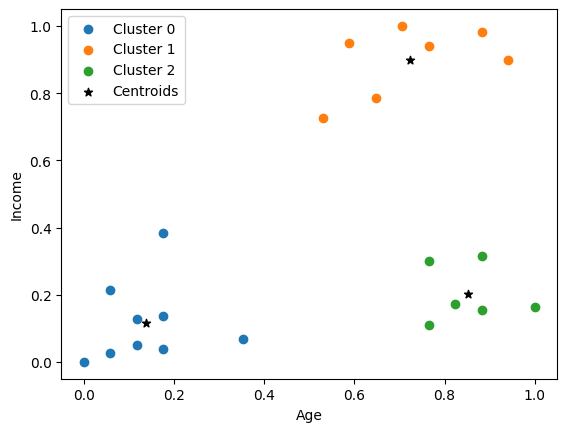

In [26]:
df1 = df[df.cluster == 0]
df2 = df[df.cluster == 1]
df3 = df[df.cluster == 2]

plt.scatter(df1.Age, df1['Income($)'], label='Cluster 0')
plt.scatter(df2.Age, df2['Income($)'], label='Cluster 1')
plt.scatter(df3.Age, df3['Income($)'], label='Cluster 2')

plt.scatter(km.cluster_centers_[:,0],
            km.cluster_centers_[:,1],
            color='black', marker='*', label='Centroids')

plt.xlabel('Age')
plt.ylabel('Income')
plt.legend()
plt.show()

After Standard Scaling

In [27]:
scaler= StandardScaler()
scaler.fit(df[['Income($)']])
df['Income($)']=scaler.transform(df[['Income($)']])

scaler.fit(df[['Age']])
df['Age']=scaler.transform(df[['Age']])

In [31]:
km = KMeans(n_clusters=3, random_state=0)
y_predicted = km.fit_predict(df[['Age', 'Income($)']])

In [32]:
df['cluster']=y_predicted
df.head()

,Name,Age,Income($),cluster
0,Rob,-1.356055,-0.480684,0
1,Michael,-1.009157,-0.010159,0
2,Mohan,-1.009157,-0.692421,0
3,Ismail,-1.182606,-0.715947,0
4,Kory,1.245679,1.401417,1


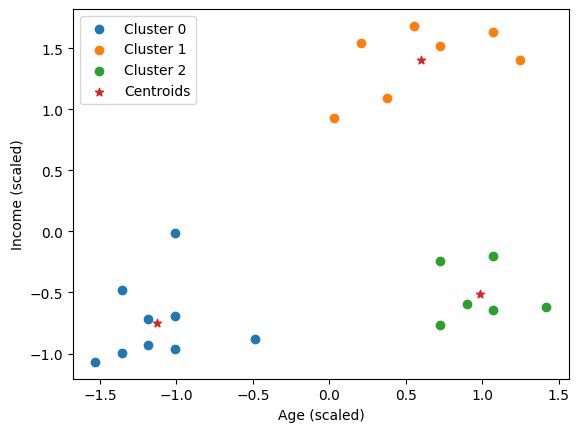

In [33]:
df0 = df[df.cluster == 0]
df1 = df[df.cluster == 1]
df2 = df[df.cluster == 2]

plt.scatter(df0['Age'], df0['Income($)'], label='Cluster 0')
plt.scatter(df1['Age'], df1['Income($)'], label='Cluster 1')
plt.scatter(df2['Age'], df2['Income($)'], label='Cluster 2')

plt.scatter(
    km.cluster_centers_[:, 0],
    km.cluster_centers_[:, 1],
    marker='*',
    label='Centroids'
)

plt.xlabel('Age (scaled)')
plt.ylabel('Income (scaled)')
plt.legend()
plt.show()


Elbow Method

In [ ]:
sse = []
k_rng = range(1, 10)

for k in k_rng:
    km = KMeans(n_clusters=k, random_state=0)
    km.fit(df[['Age', 'Income($)']])
    sse.append(km.inertia_)

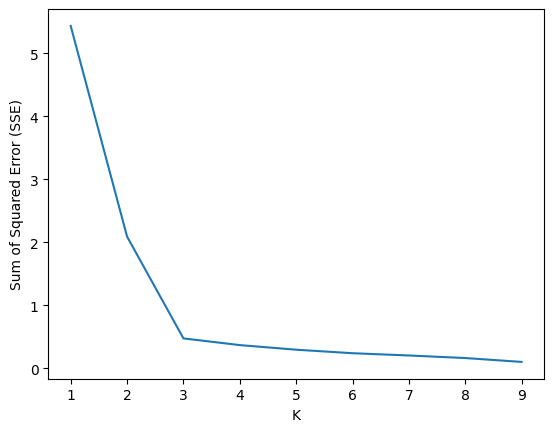

In [ ]:
plt.plot(k_rng, sse)
plt.xlabel('K')
plt.ylabel('Sum of Squared Error (SSE)')
plt.show()